<a href="https://colab.research.google.com/github/mohammedh897/Prediction-of-Product-Sales/blob/main/Model_Interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 7: Model Interpretation
### Prediction of Product Sales — Coefficients & Feature Importances



## 0. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All imports successful.")

All imports successful.


## 1. Load & Prepare Data

In [15]:
df = pd.read_csv('https://drive.google.com/uc?id=135h5PAFcANKJRTIcrgIiFEtLMJIukb0t')
# Fix inconsistent categories
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'low fat', 'Low Fat': 'low fat', 'low fat': 'low fat',
    'Reg': 'regular', 'reg': 'regular', 'Regular': 'regular'
})
y = df['Item_Outlet_Sales']
X = df.drop(columns=['Item_Identifier', 'Item_Outlet_Sales'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
df.head()

Train: (6392, 10)  |  Test: (2131, 10)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,low fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,low fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,low fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 2. Rebuild Preprocessing Pipeline

In [5]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
ordinal_features   = ['Outlet_Size', 'Outlet_Location_Type']
all_object_features = X.select_dtypes(include=['object']).columns.tolist()
nominal_features   = [c for c in all_object_features if c not in ordinal_features]

outlet_size_order          = ['Small', 'Medium', 'High']
outlet_location_type_order = ['Tier 1', 'Tier 2', 'Tier 3']

numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])
ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[outlet_size_order, outlet_location_type_order],
                               handle_unknown='use_encoded_value', unknown_value=-1)),
    ('scaler',  StandardScaler())
])
nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_features),
    ('ord', ordinal_transformer,   ordinal_features),
    ('nom', nominal_transformer,   nominal_features)
])

preprocessor.fit(X_train)
X_train_tf = preprocessor.transform(X_train)
X_test_tf  = preprocessor.transform(X_test)

# Recover feature names
ohe            = preprocessor.named_transformers_['nom'].named_steps['onehot']
nominal_names  = ohe.get_feature_names_out(nominal_features).tolist()
all_feature_names = numerical_features + ordinal_features + nominal_names

X_train_tf = pd.DataFrame(X_train_tf, columns=all_feature_names, index=X_train.index)
X_test_tf  = pd.DataFrame(X_test_tf,  columns=all_feature_names, index=X_test.index)

print("Feature names recovered:", len(all_feature_names), "features")
print(all_feature_names[:10], "...")

Feature names recovered: 38 features
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Item_Fat_Content_low fat', 'Item_Fat_Content_regular', 'Item_Type_Baking Goods', 'Item_Type_Breads'] ...


## 3. Linear Regression — Coefficients

In [6]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_tf, y_train)

# Build a clean DataFrame of coefficients
coef_df = pd.DataFrame({
    'Feature':     all_feature_names,
    'Coefficient': lin_reg.coef_
})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)
print("Top 10 coefficients by absolute magnitude:")
coef_df.head(10)

Top 10 coefficients by absolute magnitude:


,Feature,Coefficient
0,Outlet_Type_Grocery Store,-1092.126268
1,Item_MRP,984.513074
2,Outlet_Identifier_OUT027,766.422868
3,Outlet_Type_Supermarket Type3,766.422868
4,Outlet_Identifier_OUT010,-651.475651
5,Outlet_Identifier_OUT019,-440.650617
6,Outlet_Type_Supermarket Type1,330.587284
7,Item_Type_Seafood,308.888596
8,Outlet_Identifier_OUT049,198.948636
9,Outlet_Identifier_OUT013,-176.601148


### 3a. Visualize All Coefficients (sorted by value)

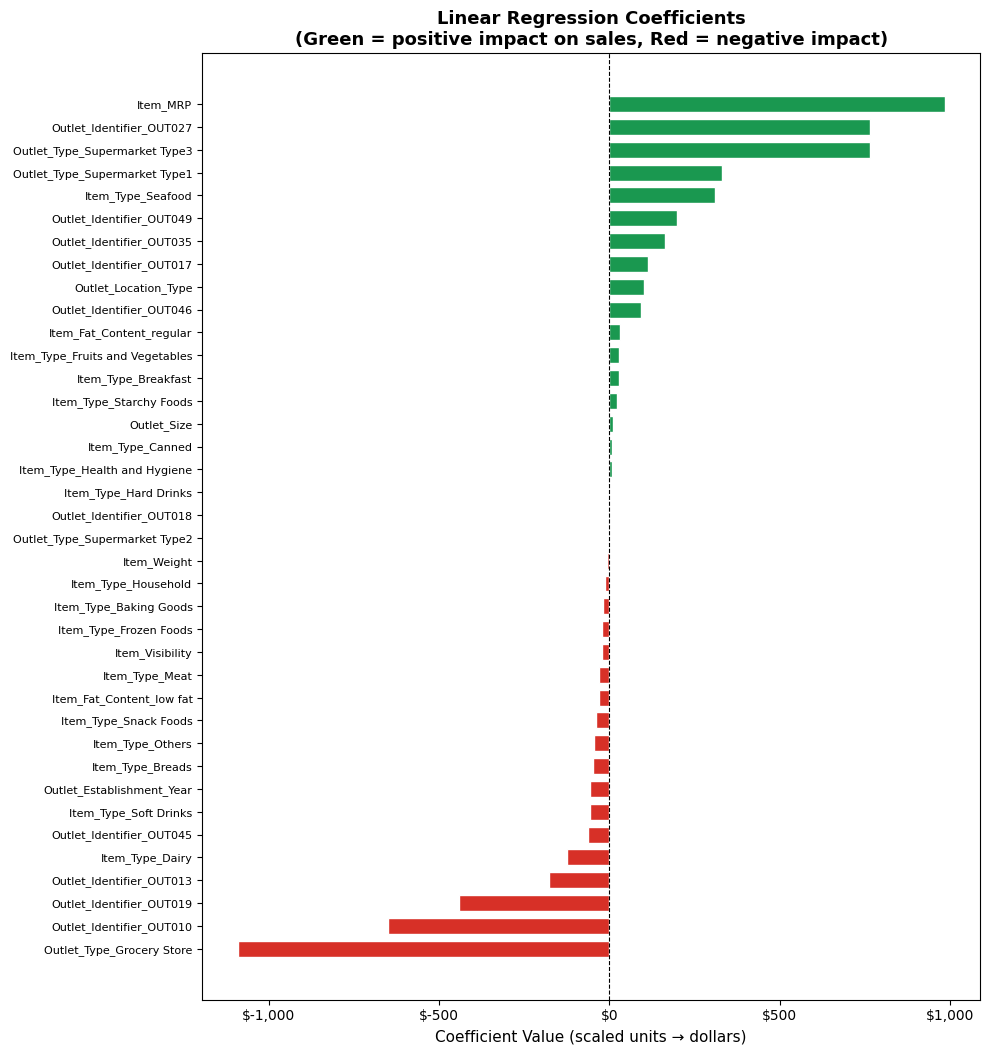

Saved: lr_coefficients.png


In [7]:
# Sort by raw value so positive/negative is clear
plot_df = coef_df.sort_values('Coefficient', ascending=True)

colors = ['#d73027' if v < 0 else '#1a9850' for v in plot_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.28)))
bars = ax.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value (scaled units → dollars)', fontsize=11)
ax.set_title('Linear Regression Coefficients\n(Green = positive impact on sales, Red = negative impact)', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lr_coefficients.png")

### 3b. Top 3 Most Impactful Features — Plain-Language Explanation

Run the cell below to identify and explain the top 3 features.

In [8]:
top3 = coef_df.head(3)
print("=" * 60)
print("TOP 3 MOST IMPACTFUL LINEAR REGRESSION FEATURES")
print("=" * 60)
for _, row in top3.iterrows():
    direction = "INCREASES" if row['Coefficient'] > 0 else "DECREASES"
    print(f"\n► {row['Feature']}")
    print(f"   Coefficient: ${row['Coefficient']:,.2f}")
    print(f"   Meaning: A one-unit increase in this (scaled) feature")
    print(f"   {direction} predicted sales by ${abs(row['Coefficient']):,.2f}")

TOP 3 MOST IMPACTFUL LINEAR REGRESSION FEATURES

► Outlet_Type_Grocery Store
   Coefficient: $-1,092.13
   Meaning: A one-unit increase in this (scaled) feature
   DECREASES predicted sales by $1,092.13

► Item_MRP
   Coefficient: $984.51
   Meaning: A one-unit increase in this (scaled) feature
   INCREASES predicted sales by $984.51

► Outlet_Identifier_OUT027
   Coefficient: $766.42
   Meaning: A one-unit increase in this (scaled) feature
   INCREASES predicted sales by $766.42


## 4. Tuned Random Forest — Feature Importances

In [9]:
# Re-run the same GridSearchCV as Part 6
param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5, n_jobs=-1, verbose=0
)
grid_search.fit(X_train_tf, y_train)
best_rf = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)
print(f"Best CV RMSE: ${np.sqrt(-grid_search.best_score_):,.2f}")

Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV RMSE: $1,103.52


In [10]:
# Build feature importance DataFrame
fi_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 10 most important features:")
fi_df.head(10)

Top 10 most important features:


,Feature,Importance
0,Item_MRP,0.510741
1,Outlet_Type_Grocery Store,0.262647
2,Item_Visibility,0.046086
3,Outlet_Identifier_OUT027,0.043801
4,Outlet_Type_Supermarket Type3,0.042252
5,Outlet_Establishment_Year,0.023790
6,Item_Weight,0.019634
7,Item_Type_Fruits and Vegetables,0.003268
8,Item_Type_Snack Foods,0.003188
9,Item_Type_Soft Drinks,0.003161


### 4a. Visualize Feature Importances (Top 20)

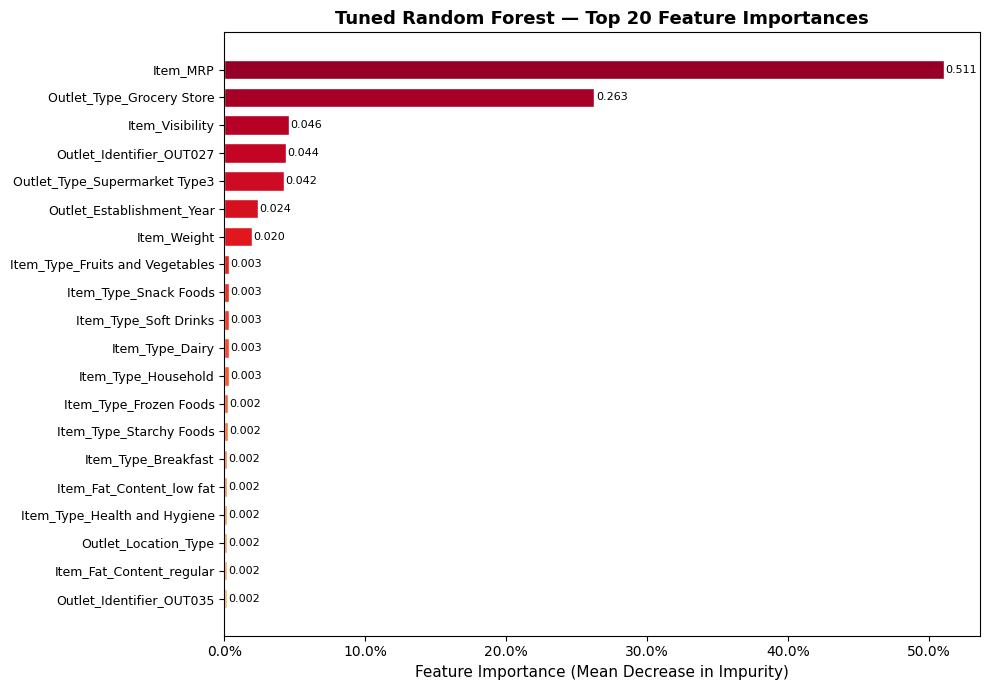

Saved: rf_feature_importances.png


In [11]:
top20 = fi_df.head(20).sort_values('Importance', ascending=True)

palette = plt.cm.YlOrRd(np.linspace(0.35, 0.95, len(top20)))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20['Feature'], top20['Importance'], color=palette, edgecolor='white', height=0.7)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Tuned Random Forest — Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

# Annotate bars with value
for bar, val in zip(bars, top20['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('rf_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rf_feature_importances.png")

### 4b. Top 5 Most Important Features — Plain-Language Explanation

In [12]:
top5 = fi_df.head(5)
print("=" * 60)
print("TOP 5 MOST IMPORTANT RANDOM FOREST FEATURES")
print("=" * 60)
for rank, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"\n#{rank}  {row['Feature']}")
    print(f"     Importance score: {row['Importance']:.4f} ({row['Importance']*100:.1f}% of total)")
    print(f"     This feature was the #{rank} most useful split point")
    print(f"     across all {best_rf.n_estimators} trees in the forest.")

TOP 5 MOST IMPORTANT RANDOM FOREST FEATURES

#1  Item_MRP
     Importance score: 0.5107 (51.1% of total)
     This feature was the #1 most useful split point
     across all 300 trees in the forest.

#2  Outlet_Type_Grocery Store
     Importance score: 0.2626 (26.3% of total)
     This feature was the #2 most useful split point
     across all 300 trees in the forest.

#3  Item_Visibility
     Importance score: 0.0461 (4.6% of total)
     This feature was the #3 most useful split point
     across all 300 trees in the forest.

#4  Outlet_Identifier_OUT027
     Importance score: 0.0438 (4.4% of total)
     This feature was the #4 most useful split point
     across all 300 trees in the forest.

#5  Outlet_Type_Supermarket Type3
     Importance score: 0.0423 (4.2% of total)
     This feature was the #5 most useful split point
     across all 300 trees in the forest.
